# Model Validation and Regularisation on the Iris Dataset

Building, validating and regularising a fully connected neural network in TensorFlow 2 / Keras.

## Overview

The goal of this project is to train a neural network that classifies the three species of the Iris
dataset and, more importantly, to go through the full workflow that turns a model that *memorises*
the training set into one that actually *generalises*.

The notebook covers, in order:

1. Loading the data and splitting it into training, validation and test sets.
2. Building and training a deliberately oversized baseline model.
3. Diagnosing overfitting from the learning curves.
4. Reducing overfitting with **L2 weight decay**, **dropout** and **batch normalisation**.
5. Adding the **EarlyStopping** and **ReduceLROnPlateau** callbacks to control the training run.
6. Comparing the three runs.

<table>
  <tr>
    <td><img src="data/iris_setosa.jpg" alt="Iris setosa" height="240"/></td>
    <td><img src="data/iris_versicolor.jpg" alt="Iris versicolor" height="240"/></td>
    <td><img src="data/iris_virginica.jpg" alt="Iris virginica" height="240"/></td>
  </tr>
  <tr>
    <td align="center"><b>Iris setosa</b></td>
    <td align="center"><b>Iris versicolor</b></td>
    <td align="center"><b>Iris virginica</b></td>
  </tr>
</table>

## 1. The Iris dataset

The Iris dataset consists of 150 samples, 50 from each of three species of Iris (*Iris setosa*,
*Iris versicolor* and *Iris virginica*). Four features were measured on every sample: the length and
the width of the sepals and of the petals, in centimetres.

|  |  |
|---|---|
| Samples | 150 (50 per class) |
| Features | sepal length, sepal width, petal length, petal width (cm) |
| Classes | setosa, versicolor, virginica |
| Task | multi-class classification |

It is a small and well separated dataset, which makes it a good playground for validation and
regularisation: a network with tens of thousands of parameters can fit it perfectly in a few epochs,
so any gap between the training and the validation curves is easy to see.

**References**

- R. A. Fisher, *The use of multiple measurements in taxonomic problems*, Annals of Eugenics, 7(2), 179-188, 1936.
- Dua, D. and Graff, C. (2019). [UCI Machine Learning Repository - Iris](https://archive.ics.uci.edu/ml/datasets/iris).

## 2. Libraries and setup

TensorFlow/Keras for the model, scikit-learn for the dataset and the train/test split, and
matplotlib for the learning curves. The NumPy seed is fixed so the runs are easier to compare.

In [1]:
# Import Libraries

from numpy.random import seed
seed(8)
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, model_selection


%matplotlib inline

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.regularizers import l2

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## 3. Load and preprocess the data

The data is split into a training set and a **test set that is held out** and never used during
training. The labels come as integers (`0`, `1`, `2`), so they are one-hot encoded into vectors of
length 3 to match the softmax output and the `categorical_crossentropy` loss.

The validation set is not created here: it is carved out of the training set later by Keras, through
the `validation_split` argument of `model.fit`.

In [2]:
# 90% training / 10% test: the test set is kept aside until the very end
def read_in_and_split_data(iris_data):

    train_data, test_data, train_targets, test_targets = train_test_split(
        iris_data.data, iris_data.target, test_size=0.1)

    return (train_data, test_data, train_targets, test_targets)

In [3]:
# Load the dataset and apply the split
iris_data = datasets.load_iris()
train_data, test_data, train_targets, test_targets = read_in_and_split_data(iris_data)

In [4]:
# Integer labels -> one-hot vectors, as expected by categorical_crossentropy
train_targets = tf.keras.utils.to_categorical(np.array(train_targets))
test_targets = tf.keras.utils.to_categorical(np.array(test_targets))

## 4. Build the neural network

A fully connected (feed-forward) network with ten `Dense` layers: a 64-unit input layer, four
128-unit layers, four 64-unit layers and a 3-unit softmax output, one unit per class.

All hidden layers use ReLU activations, and the first one is initialised with He uniform weights (a
sensible default for ReLU) and a bias of ones.

The architecture is intentionally much larger than the problem requires. That is the point: it gives
the network enough capacity to memorise the training set, so the overfitting that is fixed in the
next sections is clearly visible.

In [5]:
# 10 dense layers: 64 -> 128 x4 -> 64 x4 -> 3 (softmax, one unit per class)
def get_model(input_shape):
    model = Sequential([
        Dense(64, activation='relu', input_shape=input_shape, kernel_initializer='he_uniform',
              bias_initializer='ones'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(3, activation='softmax')
    ])

    return model

    

In [6]:
# input_shape is taken from a single sample: (4,)
model = get_model(train_data[0].shape)

c:\Users\ramir\OneDrive\Documents\ESTUDIO\DEEP LEARNING\Tensorflow 2 for Deep Learning\PROYECTOS\tf2-cnn-mnist-classifier\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,107 (309.01 KB)

 Trainable params: 79,107 (309.01 KB)

 Non-trainable params: 0 (0.00 B)

Around **79,000 trainable parameters** for 114 training samples, that is several hundred parameters
per sample. With that much capacity, the model is expected to drive the training loss to zero.

## 5. Compile the model

The model is compiled with the **Adam** optimiser (learning rate `0.0001`),
**categorical cross-entropy** as the loss (the standard choice for one-hot encoded multi-class
targets) and **accuracy** as the reported metric.

Wrapping this in a function keeps the three models of the notebook compiled in exactly the same way,
so the only thing that changes between the runs is the regularisation.

In [8]:
# Adam + categorical cross-entropy, reused by the three models
def compile_model(model):

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics = ['accuracy'])

In [9]:
compile_model(model)

## 6. Train the baseline model

The model is trained for 800 epochs with a batch size of 40. `validation_split=0.15` reserves the
last 15% of the training data as a validation set, which is evaluated at the end of every epoch and
never used to update the weights: it is the signal used to detect overfitting.

In [10]:
# validation_split: the last 15% of the training data is used for validation only
def train_model(model, train_data, train_targets, epochs):

    history = model.fit(train_data, train_targets, epochs=epochs,
                        batch_size=40, validation_split=0.15)
    return history

In [11]:
history = train_model(model, train_data, train_targets, epochs=800)

Epoch 1/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.3158 - loss: 1.1490 - val_accuracy: 0.4286 - val_loss: 1.1030
Epoch 2/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5000 - loss: 1.0941 - val_accuracy: 0.6190 - val_loss: 1.0635
Epoch 3/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6667 - loss: 1.0581 - val_accuracy: 0.6190 - val_loss: 1.0411
Epoch 4/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6667 - loss: 1.0266 - val_accuracy: 0.6190 - val_loss: 1.0162
Epoch 5/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6667 - loss: 0.9983 - val_accuracy: 0.6190 - val_loss: 0.9923
Epoch 6/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6842 - loss: 0.9757 - val_accuracy: 0.7619 - val_loss: 0.9703
Epoch 7/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7982 - loss: 0.9527 - val_accuracy: 0.7619 - val_loss: 0.9525
Epoch 8/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8070 - loss: 0.9308 - val_accuracy: 0.7619 - val_loss:

### Learning curves of the baseline model

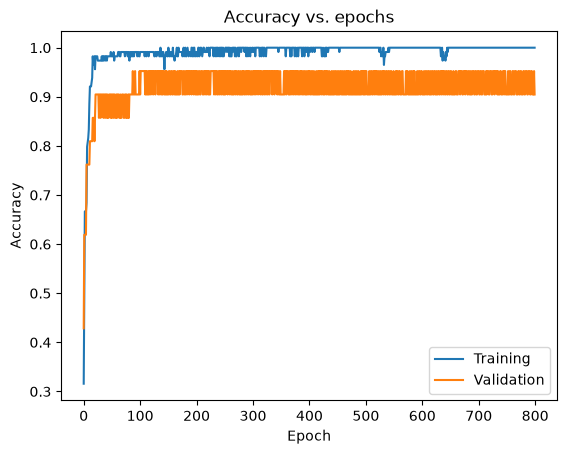

In [12]:
# Accuracy curves (the except branch covers older Keras versions, which used 'acc')
try:
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
except KeyError:
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
plt.title('Accuracy vs. epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show() 

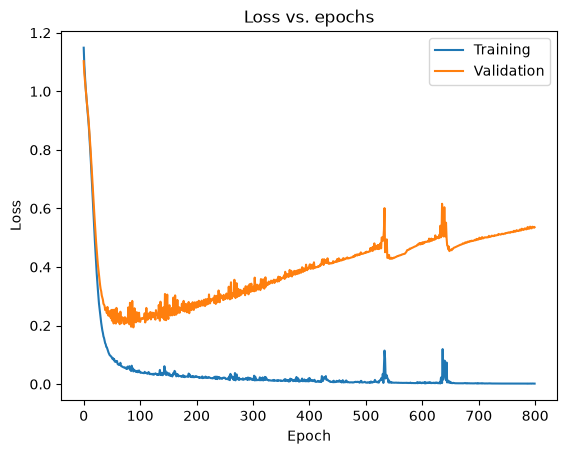

In [13]:
# Loss curves
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show() 

**Diagnosis: the model is overfitting.**

The validation loss bottoms out at `0.1937` around epoch 89 and then climbs steadily up to `0.5358`
by epoch 800, while the training loss keeps falling all the way down to `0.0017` and the training
accuracy sits at 100%.

That divergence is the classic signature of overfitting: the network keeps reducing the error on the
data it has already seen and, in doing so, becomes *more* confident about its mistakes on the data
it has not. Everything after epoch ~89 makes the model worse on unseen data, not better.

Note also that the validation accuracy stays flat around 90-95% the whole time. Accuracy alone would
never have revealed the problem; the loss does.

## 7. Reducing overfitting with regularisation

Three techniques are combined on the same architecture:

- **L2 weight decay** (`kernel_regularizer=l2(weight_decay)`) adds a penalty proportional to the
  squared weights to the loss, pushing the network towards smaller weights and smoother decision
  boundaries.
- **Dropout** randomly deactivates a fraction of the units at every training step, which prevents
  the layers from relying on a few specific neurons.
- **Batch normalisation** normalises the activations inside the network, which stabilises and
  usually speeds up training.

In [14]:
# Same architecture as before + L2 weight decay, dropout and batch normalisation
def get_regularised_model(input_shape, dropout_rate, weight_decay):
    model = Sequential([
            Dense(64, activation='relu', input_shape=input_shape, kernel_initializer='he_uniform',
                  bias_initializer='ones', kernel_regularizer=l2(weight_decay)),
            Dense(128, activation='relu', kernel_regularizer=l2(weight_decay)),
            Dense(128, activation='relu', kernel_regularizer=l2(weight_decay)),
            Dropout(dropout_rate),
            Dense(128, activation='relu', kernel_regularizer=l2(weight_decay)),
            Dense(128, activation='relu', kernel_regularizer=l2(weight_decay)),
            BatchNormalization(),
            Dense(64, activation='relu', kernel_regularizer=l2(weight_decay)),
            Dense(64, activation='relu', kernel_regularizer=l2(weight_decay)),
            Dropout(dropout_rate),
            Dense(64, activation='relu', kernel_regularizer=l2(weight_decay)),
            Dense(64, activation='relu', kernel_regularizer=l2(weight_decay)),
            Dense(3, activation='softmax')
        ])
    
    return model

### Compile and train the regularised model

Same depth and width as before, now with a dropout rate of `0.3` and an L2 weight decay of `0.001`,
trained with the same optimiser, batch size and number of epochs so the comparison is fair.

In [15]:
# dropout_rate = 0.3, weight_decay = 0.001
reg_model = get_regularised_model(train_data[0].shape, 0.3, 0.001)

In [16]:
compile_model(reg_model)

In [17]:
reg_history = train_model(reg_model, train_data, train_targets, epochs=800)

Epoch 1/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.3509 - loss: 1.9918 - val_accuracy: 0.3810 - val_loss: 1.9917
Epoch 2/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3596 - loss: 1.9727 - val_accuracy: 0.3810 - val_loss: 1.9732
Epoch 3/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3421 - loss: 1.9659 - val_accuracy: 0.3810 - val_loss: 1.9583
Epoch 4/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3772 - loss: 1.9485 - val_accuracy: 0.3810 - val_loss: 1.9438
Epoch 5/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4561 - loss: 1.9570 - val_accuracy: 0.3810 - val_loss: 1.9305
Epoch 6/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3596 - loss: 1.9725 - val_accuracy: 0.3810 - val_loss: 1.9177
Epoch 7/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4298 - loss: 1.9348 - val_accuracy: 0.3810 - val_loss: 1.9074
Epoch 8/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4386 - loss: 1.9359 - val_accuracy: 0.3810 - val_loss:

### Learning curves of the regularised model

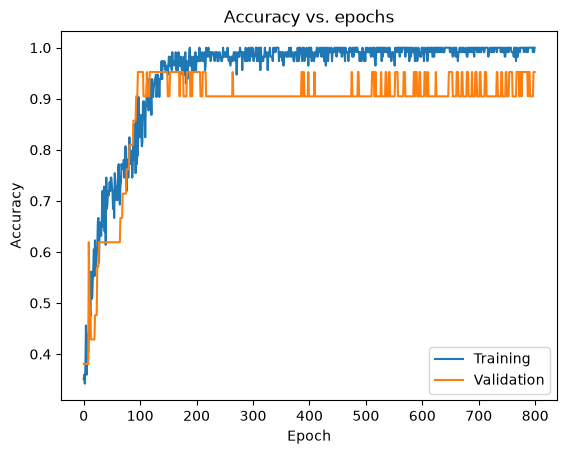

In [18]:
# Accuracy curves of the regularised model
try:
    plt.plot(reg_history.history['accuracy'])
    plt.plot(reg_history.history['val_accuracy'])
except KeyError:
    plt.plot(reg_history.history['acc'])
    plt.plot(reg_history.history['val_acc'])
plt.title('Accuracy vs. epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show() 

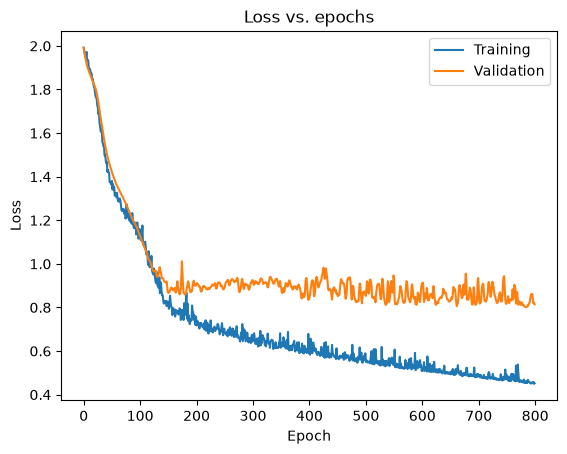

In [19]:
# Loss curves of the regularised model
plt.plot(reg_history.history['loss'])
plt.plot(reg_history.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show() 

**Regularisation removes the divergence.**

At first sight the numbers look worse: the final validation loss is `0.8146` against the `0.5358` of
the baseline. That is expected, because the reported loss of this model **includes the L2 penalty**,
so the absolute values are not comparable between the two runs.

The fair comparison is the *gap* between the training and the validation loss, where the penalty
appears in both terms and cancels out:

| At epoch 800 | Train loss | Val. loss | Gap |
|---|---|---|---|
| Baseline | 0.0017 | 0.5358 | **0.534** |
| Regularised | 0.4522 | 0.8146 | **0.362** |

And above all, the *shape* changed. Instead of bottoming out at epoch 89 and rising from there, the
validation loss of the regularised model keeps going down until the end of the run: its best value,
`0.8018`, comes at epoch 785 out of 800. The final validation accuracy also improved, from 90.48% to
95.24%.

The price is speed. With the same learning rate, this model needs around 150 epochs to reach the
training accuracy that the baseline reached in about 25, and after 800 epochs it has still not
finished converging. The curves are also noisier, which is expected: dropout and batch normalisation
behave differently at training and at validation time.

## 8. Callbacks: early stopping and learning rate reduction

Regularisation fixed *how* the model learns; callbacks fix *when it should stop*. Instead of fixing
800 epochs by hand, the training run is now controlled by two callbacks:

- **`EarlyStopping`** monitors the validation loss and interrupts training when it stops improving
  for `patience=30` consecutive epochs, which avoids the wasted (and harmful) epochs seen above.
- **`ReduceLROnPlateau`** multiplies the learning rate by `factor=0.2` when the validation loss
  plateaus for `patience=20` epochs, letting the optimiser take finer steps once it is close to a
  minimum.

In [20]:
# Stop when the validation loss stops improving, and lower the LR on plateaus
def get_callbacks():

    early_stopping = EarlyStopping(mode='min', patience=30)
    learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss',
                                                patience=20,
                                                factor=0.2)

    return early_stopping,learning_rate_reduction

This last run uses a lighter weight decay (`0.0001`) and lets the callbacks decide the length of the
training, with `verbose=2` to keep one line per epoch in the log.

In [21]:
# Third run: lighter weight decay and training length decided by the callbacks
call_model = get_regularised_model(train_data[0].shape, 0.3, 0.0001)
compile_model(call_model)
early_stopping, learning_rate_reduction = get_callbacks()
call_history = call_model.fit(train_data, train_targets, epochs=800, validation_split=0.15,
                         callbacks=[early_stopping, learning_rate_reduction], verbose=2)

Epoch 1/800
4/4 - 2s - 454ms/step - accuracy: 0.3246 - loss: 1.2153 - val_accuracy: 0.3333 - val_loss: 1.1745 - learning_rate: 1.0000e-04
Epoch 2/800
4/4 - 0s - 15ms/step - accuracy: 0.3772 - loss: 1.1895 - val_accuracy: 0.6190 - val_loss: 1.1594 - learning_rate: 1.0000e-04
Epoch 3/800
4/4 - 0s - 16ms/step - accuracy: 0.3947 - loss: 1.1613 - val_accuracy: 0.6190 - val_loss: 1.1488 - learning_rate: 1.0000e-04
Epoch 4/800
4/4 - 0s - 14ms/step - accuracy: 0.3596 - loss: 1.1943 - val_accuracy: 0.6190 - val_loss: 1.1359 - learning_rate: 1.0000e-04
Epoch 5/800
4/4 - 0s - 14ms/step - accuracy: 0.3246 - loss: 1.2103 - val_accuracy: 0.6190 - val_loss: 1.1201 - learning_rate: 1.0000e-04
Epoch 6/800
4/4 - 0s - 14ms/step - accuracy: 0.3596 - loss: 1.1834 - val_accuracy: 0.6190 - val_loss: 1.1060 - learning_rate: 1.0000e-04
Epoch 7/800
4/4 - 0s - 14ms/step - accuracy: 0.4035 - loss: 1.1520 - val_accuracy: 0.6190 - val_loss: 1.0970 - learning_rate: 1.0000e-04
Epoch 8/800
4/4 - 0s - 14ms/step - accur

In [22]:
# Check the patience actually used by the learning rate callback
learning_rate_reduction.patience

20

### Learning curves with early stopping and ReduceLROnPlateau

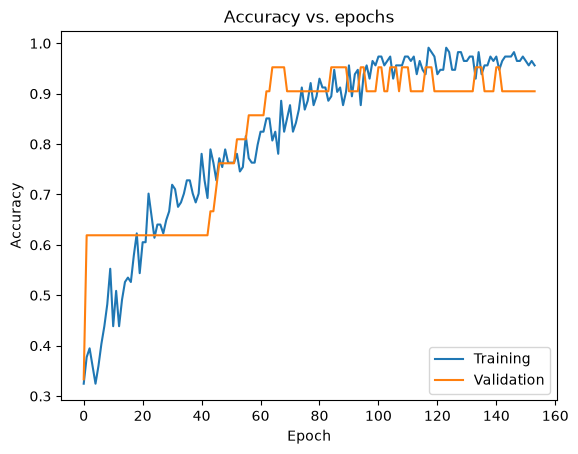

In [23]:
# Accuracy curves with callbacks
try:
    plt.plot(call_history.history['accuracy'])
    plt.plot(call_history.history['val_accuracy'])
except KeyError:
    plt.plot(call_history.history['acc'])
    plt.plot(call_history.history['val_acc'])
plt.title('Accuracy vs. epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show() 

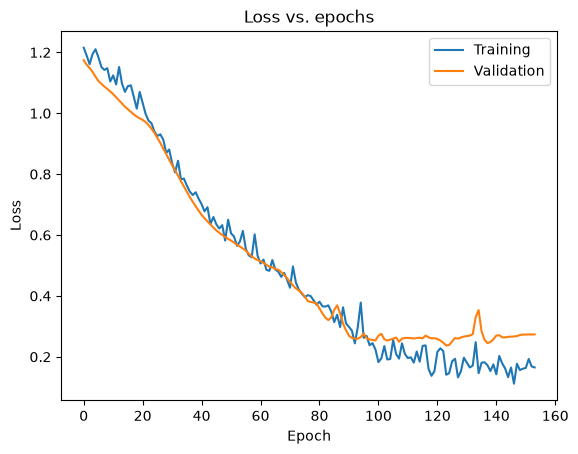

In [24]:
# Loss curves with callbacks
plt.plot(call_history.history['loss'])
plt.plot(call_history.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show() 

**The callbacks do their job.**

Training stopped at **epoch 154 out of 800**. The best validation loss (`0.2371`) was reached at
epoch 124 and, 30 epochs later without improvement, `EarlyStopping` pulled the plug. Along the way
`ReduceLROnPlateau` dropped the learning rate once, from `1e-4` to `2e-5`, at epoch 145.

These are the healthiest curves of the three runs: training and validation losses fall together and
end at `0.1651` and `0.2735`, a gap of just `0.11` against the `0.53` of the baseline, and all of it
in a fifth of the epochs.

One detail worth noticing: `EarlyStopping` was not given `restore_best_weights=True`, so the model
kept in memory is the one from epoch 154, not the better one from epoch 124.

## 9. Evaluate the model on the test set

Time to use the 15 samples that were held out at the very beginning and never seen during training
or validation. This is the only unbiased estimate of how the model behaves on new data, and it is
the number that should be reported.

In [25]:
# Final evaluation of the callback-trained model on the held-out test set
test_loss, test_acc = call_model.evaluate(test_data, test_targets, verbose=0)
print("Test loss: {:.3f}\nTest accuracy: {:.2f}%".format(test_loss, 100 * test_acc))

Test loss: 0.209
Test accuracy: 86.67%


**Test loss `0.209`, test accuracy `86.67%`**, that is 13 of the 15 held-out samples classified
correctly.

Two mistakes out of 15. The figure has to be read with care: on a test set this small a single
sample is worth 6.7% of accuracy, so the uncertainty around that 86.67% is wide. What is meaningful
is that the test loss (`0.209`) is in line with the validation loss (`0.274`), which is what a model
that generalises looks like, with no nasty surprise when it meets genuinely new data.

## 10. Summary and results

### What was done

Starting from the Iris dataset (150 samples, 4 features, 3 classes), the data was split into
**135 training samples and 15 test samples** (`test_size=0.1`), and the labels were one-hot encoded.
During training, Keras further reserved 15% of the training data as a validation set, leaving
**114 samples for training and 21 for validation**.

The same ten-layer fully connected architecture (79,107 parameters, ReLU hidden layers, softmax
output) was then trained three times, always with Adam (`lr=0.0001`) and categorical cross-entropy,
changing only how the training was regularised and controlled:

| # | Run | Regularisation | Callbacks | Epochs run |
|---|-----|----------------|-----------|------------|
| 1 | Baseline | none | none | 800 |
| 2 | Regularised | L2 `1e-3` + dropout `0.3` + batch norm | none | 800 |
| 3 | Regularised + callbacks | L2 `1e-4` + dropout `0.3` + batch norm | EarlyStopping (`patience=30`), ReduceLROnPlateau (`patience=20`, `factor=0.2`) | **154** (stopped early) |

### Results

| Run | Final train acc. | Final val. acc. | Best val. loss | Final val. loss | Gap (val - train loss) |
|-----|------------------|-----------------|----------------|-----------------|------------------------|
| 1 - Baseline | 1.0000 | 0.9048 | 0.1937 (epoch 89) | 0.5358 | 0.534 |
| 2 - Regularised | 1.0000 | 0.9524 | 0.8018 (epoch 785) | 0.8146 | 0.362 |
| 3 - Regularised + callbacks | 0.9561 | 0.9048 | 0.2371 (epoch 124) | 0.2735 | **0.108** |

*The loss of runs 2 and 3 includes the L2 penalty term, so the absolute values are not comparable
between rows. The gap in the last column is: the penalty is added to both the training and the
validation loss, so it cancels out in the difference.*

The third model, the regularised one trained with callbacks, was then evaluated on the 15 held-out
test samples:

| Metric | Value |
|--------|-------|
| Test loss | **0.209** |
| Test accuracy | **86.67%** (13/15) |

### Conclusions

- **The baseline overfits.** It reaches a perfect training accuracy and a training loss of `0.0017`
  while its validation loss almost triples from its minimum, `0.1937` at epoch 89, up to `0.5358`.
  High training accuracy on its own says nothing about generalisation, which is exactly why the
  validation set exists.
- **Watch the loss, not only the accuracy.** The validation accuracy of the baseline hovers around
  90-95% from epoch 25 to epoch 800 and never signals the problem; the validation loss does. With
  only 21 validation samples, one sample is worth 4.8% of accuracy, so the accuracy metric is too
  coarse to compare these models.
- **Regularisation does not lower the loss, it changes its shape.** L2, dropout and batch
  normalisation do not reduce the absolute validation loss (they cannot, they add a penalty to it),
  but they stop it from diverging: it keeps improving until epoch 785 of 800, the generalisation gap
  falls from `0.534` to `0.362`, and the validation accuracy rises from 90.48% to 95.24%. The cost
  is convergence speed, around six times slower to reach the same training accuracy.
- **The callbacks give the best trade-off.** Early stopping ended the run at epoch 154 out of 800,
  an 81% reduction in training time, with the smallest generalisation gap of the three runs
  (`0.108`), while ReduceLROnPlateau refined the last epochs by dropping the learning rate from
  `1e-4` to `2e-5`.
- **The final model generalises, within the limits of a 15-sample test set.** A test loss of `0.209`
  against a validation loss of `0.274` is consistent behaviour on unseen data; the 86.67% accuracy
  (13/15) is a coarse estimate that two misclassified flowers are enough to move by 13 points.
- **Bigger is not better.** ~79,000 parameters for 114 samples is an excessive model for the Iris
  dataset, and the same accuracy is reachable with a far smaller network. Here the oversized
  architecture was kept on purpose, as the setting where these techniques can be seen at work.

### Possible next steps

- Use `restore_best_weights=True` in `EarlyStopping` so the model kept is the one from epoch 124
  (val. loss `0.2371`) instead of the one from epoch 154 (`0.2735`).
- Fix the split with a `random_state` and use cross-validation, since with a test set of 15 samples
  the results vary noticeably from run to run.
- Give the regularised run more epochs, or tune the weight decay, since at epoch 800 its validation
  loss was still going down.
- Try a smaller architecture and compare it against these regularised runs.